# Rice Diseases Classification using cnn with tensorflow

# Importing libraries

In [1]:
# import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras as ks 

2026-04-28 01:48:04.502740: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 01:48:04.513915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777340884.526823      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777340884.530255      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-28 01:48:04.543369: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Load training dataset

In [2]:
# import dataset
df = pd.read_csv('/kaggle/input/paddy-disease-classification/train.csv')
df.head()

,image_id,label,variety,age
0,110054.jpg,blast,Ponni,47
1,100093.jpg,brown_spot,ADT45,68
2,106913.jpg,tungro,ADT45,65
3,103939.jpg,hispa,ADT45,68
4,103699.jpg,dead_heart,ADT45,67


# Explore the data

In [3]:
# check the shape of the dataset
print(f'{df.shape[0]} rows and {df.shape[1]} columns')

7805 rows and 4 columns


In [4]:
df['label'].unique().tolist()

['blast',
 'brown_spot',
 'tungro',
 'hispa',
 'dead_heart',
 'normal',
 'bacterial_leaf_streak',
 'downy_mildew',
 'bacterial_leaf_blight',
 'bacterial_panicle_blight']

In [5]:
df['age'].describe()

count    7805.000000
mean       64.015887
std         8.966036
min        45.000000
25%        60.000000
50%        67.000000
75%        70.000000
max        82.000000
Name: age, dtype: float64

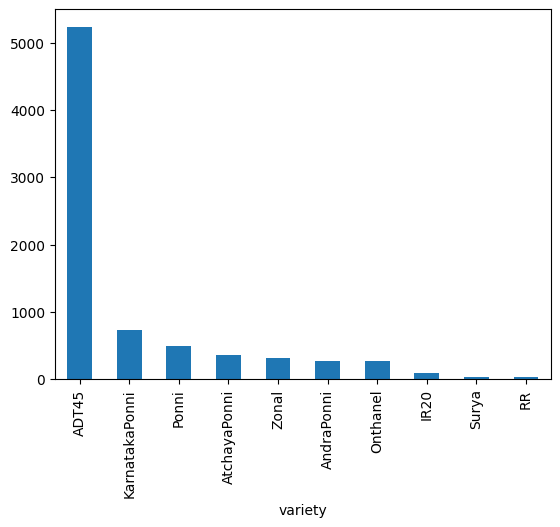

In [6]:
# Plot the data count based on variety name
df['variety'].value_counts().plot(kind='bar')
plt.show()

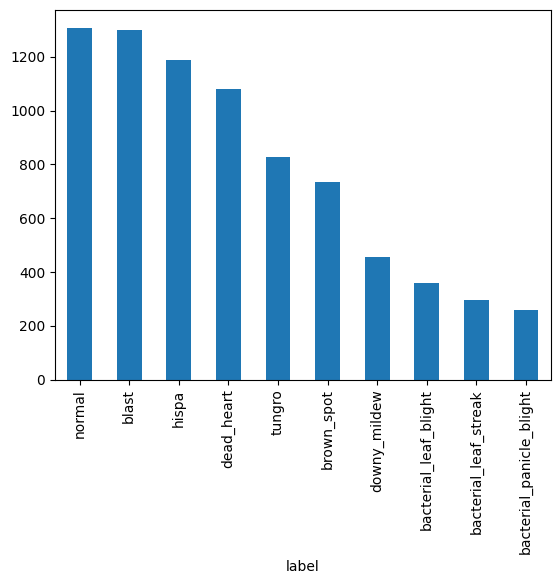

In [7]:
# Plot the data count based on variety name
df['label'].value_counts().plot(kind='bar')
plt.show()

In [8]:
normal = df[df['label'] == 'normal']
normal= normal[normal['variety'] == 'ADT45']    
five_normals = normal.image_id[18:24].values
print(five_normals.tolist())

dead = df[df['label'] == 'dead_heart']
normal= dead[dead['variety'] == 'ADT45']    
five_deads = dead.image_id[18:24].values
print(five_deads.tolist())

['107527.jpg', '106752.jpg', '104344.jpg', '104087.jpg', '100585.jpg', '103909.jpg']
['101725.jpg', '105366.jpg', '106573.jpg', '105232.jpg', '101200.jpg', '109700.jpg']


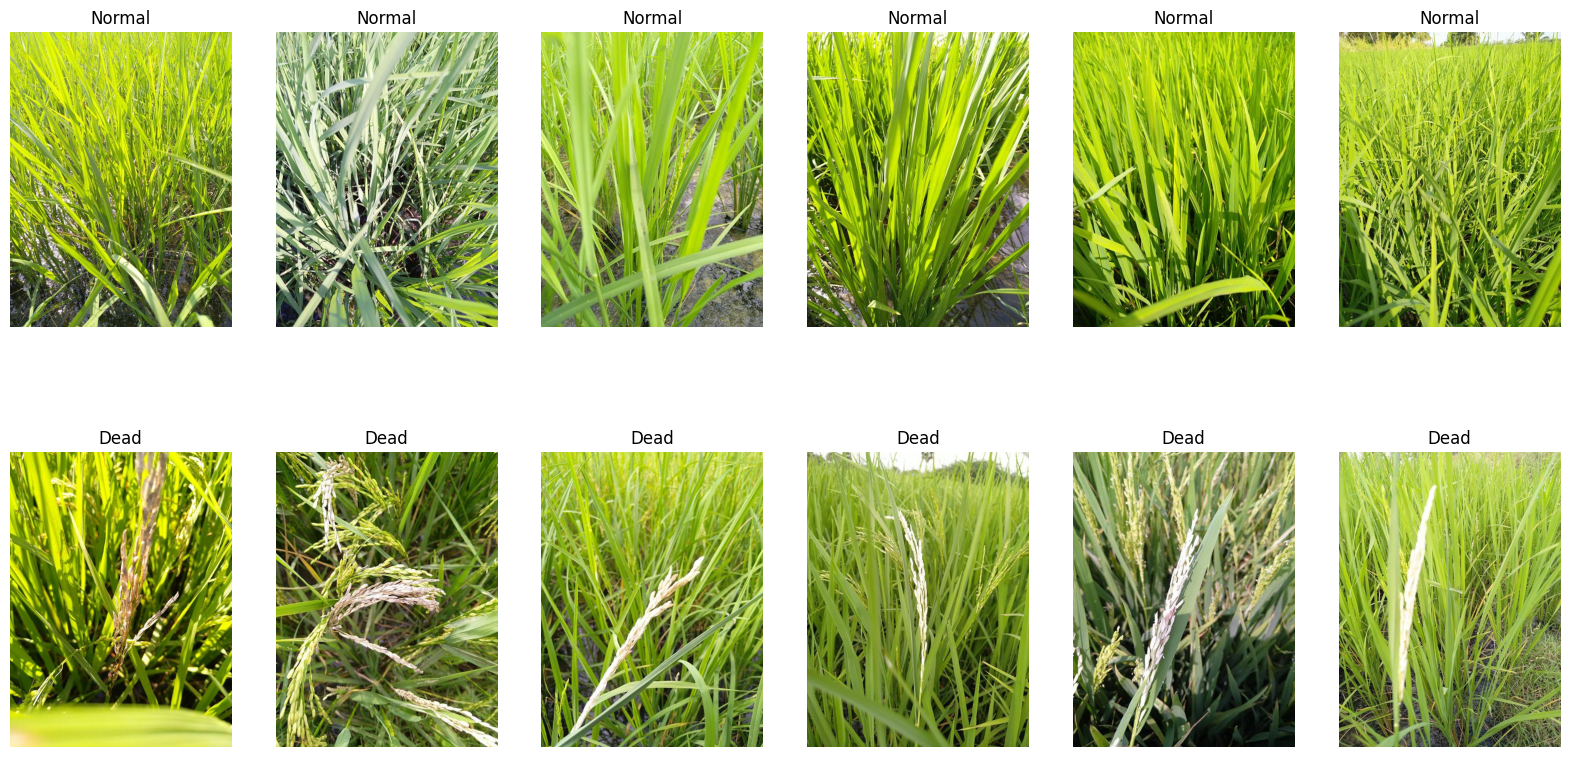

In [9]:
# Make plot of images just to have an idea
plt.figure(figsize=(20,10))
cols = 6
path = '/kaggle/input/paddy-disease-classification/train_images/'
for i, image_loc in enumerate(np.concatenate((five_normals, five_deads))):
    plt.subplot(10//cols + 1, cols, i + 1)

    if i < len(five_normals):
        img = plt.imread(path + 'normal/' + image_loc)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Normal')
    else:
        img = plt.imread(path + 'dead_heart/' + image_loc)
        plt.imshow(img)
        plt.axis('off')
        plt.title('Dead')
    


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/paddy-disease-classification/train_images/tungro/109629.jpg'

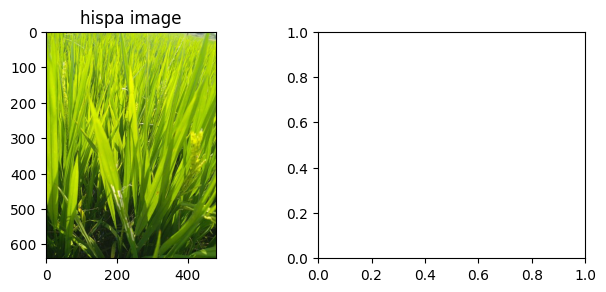

In [10]:
images = [
    '/kaggle/input/paddy-disease-classification/train_images/hispa/106590.jpg', \
    '/kaggle/input/paddy-disease-classification/train_images/tungro/109629.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/bacterial_leaf_blight/109372.jpg', \
    '/kaggle/input/paddy-disease-classification/train_images/downy_mildew/102350.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/blast/110243.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/bacterial_leaf_streak/101104.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/normal/109760.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/brown_spot/104675.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/dead_heart/105159.jpg',\
    '/kaggle/input/paddy-disease-classification/train_images/bacterial_panicle_blight/101351.jpg',\
    ]

diseases = ['hispa', 'tungro', 'bacterial_leaf_blight', 'downy_mildew', 'blast', 'bacterial',
'normal','brown_spot', 'dead_heart', 'bacterial_panicle_blight']
diseases = [disease +' image' for disease in diseases]

plt.figure(figsize=(20,10)) 
columns = 5

for i, image_loc in enumerate( images):
    plt.subplot(len(images)//columns + 1,columns, i + 1)
    image=plt. imread (image_loc)
    plt. title(diseases[i])
    plt. imshow (image)

In [11]:
df.head()

,image_id,label,variety,age
0,110054.jpg,blast,Ponni,47
1,100093.jpg,brown_spot,ADT45,68
2,106913.jpg,tungro,ADT45,65
3,103939.jpg,hispa,ADT45,68
4,103699.jpg,dead_heart,ADT45,67


# Preprocessing

In [12]:
# lets encode the label & variety columns
le_list = {}
for col in ['label', 'variety']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_list[col] = le

In [13]:
# define parameters
batch_size = 32
image_size = (224, 224)
num_classes = 10
epochs = 50

In [14]:
# split the data
train_df = ks.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset='training',
    seed=122,
    image_size=image_size,
    batch_size=batch_size
)
val_df = ks.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset='validation',
    seed=122,
    image_size=image_size,
    batch_size=batch_size
)

Found 7805 files belonging to 11 classes.
Using 6244 files for training.
Found 7805 files belonging to 11 classes.
Using 1561 files for validation.


2026-04-28 01:48:12.602572: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
# get class names
class_names = train_df.class_names  
print(class_names)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'train_images', 'tungro']


In [16]:
# lets check the shape of img
for image_batch, labels_batch in train_df:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


In [17]:
# lets normalize the data
normalization_layer = ks.layers.Rescaling(1./255)
normalized_df = train_df.map(lambda x, y: (normalization_layer(x), y))
first_image, first_label = next(iter(normalized_df))
# Check the pixel value range
print(first_image[0].numpy().min(), first_image[0].numpy().max())

0.0 1.0


In [18]:
AUTOTUNE = tf.data.AUTOTUNE
train_df = train_df.cache().prefetch(buffer_size=AUTOTUNE)
val_df = val_df.cache().prefetch(buffer_size=AUTOTUNE)

# Model Creation

In [19]:
# create the model
model = ks.Sequential([
    ks.Input(shape=(224, 224, 3)),       # Correct input shape
    ks.layers.Rescaling(1./255),

    ks.layers.Conv2D(32, 3, padding='same', activation='relu'),
    ks.layers.MaxPooling2D(),

    ks.layers.Conv2D(32, 3, padding='same', activation='relu'),
    ks.layers.MaxPooling2D(),

    ks.layers.Conv2D(64, 3, padding='same', activation='relu'),
    ks.layers.MaxPooling2D(),

    ks.layers.Conv2D(128, 3, padding='same', activation='relu'),
    ks.layers.MaxPooling2D(),

    ks.layers.Flatten(),                        # This will now be 12544
    ks.layers.Dropout(0.2),
    
    ks.layers.Dense(256, activation='relu'),    # Will automatically fit 12544 input
    ks.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,527,850 (24.90 MB)

 Trainable params: 6,527,850 (24.90 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [20]:
# train the model
history = model.fit(
    train_df,
    validation_data=val_df,
    epochs=20
)

Epoch 1/20


2026-04-28 01:48:14.444977: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 10 which is outside the valid range of [0, 10).  Label values: 3 10 8 5 0 10 8 1 3 0 10 3 8 6 8 0 3 3 7 10 6 6 8 1 6 3 7 8 10 4 8 8
2026-04-28 01:48:14.445029: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Received a label value of 10 which is outside the valid range of [0, 10).  Label values: 3 10 8 5 0 10 8 1 3 0 10 3 8 6 8 0 3 3 7 10 6 6 8 1 6 3 7 8 10 4 8 8
	 [[{{function_node __inference_one_step_on_data_2347}}{{node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits}}]]


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipyker

In [21]:
# save the model
model.save('Rice_Disease_Classification_Model.keras')

# Model Evaluation

In [22]:
# evaluate the model
loss, accuracy = model.evaluate(train_df)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

2026-04-28 01:48:15.052570: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at sparse_xent_op.cc:103 : INVALID_ARGUMENT: Received a label value of 10 which is outside the valid range of [0, 10).  Label values: 3 3 5 5 2 3 4 3 8 7 0 4 8 3 5 8 5 8 7 7 2 3 8 5 1 1 3 7 8 5 6 10
2026-04-28 01:48:15.052613: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Received a label value of 10 which is outside the valid range of [0, 10).  Label values: 3 3 5 5 2 3 4 3 8 7 0 4 8 3 5 8 5 8 7 7 2 3 8 5 1 1 3 7 8 5 6 10
	 [[{{function_node __inference_one_step_on_data_2680}}{{node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits}}]]


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipyker

### We have achieved 99.8% Accuracy.

# Predict Test data and make submission file

In [23]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# === CONFIG ===
TEST_DIR = '/kaggle/input/paddy-disease-classification/test_images/'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
# MODEL_PATH = 'model.h5'  # path to your saved model

# === Load test filenames ===
test_filenames = os.listdir(TEST_DIR)

# Create DataFrame for generator
test_df = pd.DataFrame({'filename': test_filenames})

# === Prepare Test Data Generator ===
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=TEST_DIR,
    x_col='filename',
    y_col=None,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)



# === Predict on Test Data ===
preds = model.predict(test_generator, verbose=1)
predicted_class_indices = np.argmax(preds, axis=1)

# === Get Class Labels ===
# You need to have access to train_generator.class_indices
# Example: {'bacterial_leaf_blight': 0, 'brown_spot': 1, ...}
class_names = [
    'bacterial_leaf_blight',
    'bacterial_leaf_streak',
    'bacterial_panicle_blight',
    'blast',
    'brown_spot',
    'dead_heart',
    'downy_mildew',
    'hispa',
    'normal',
    'tungro'
]

class_indices = {name: idx for idx, name in enumerate(class_names)}
labels = dict((v, k) for k, v in class_indices.items())

# Map predicted indices to class names
predicted_labels = [labels[k] for k in predicted_class_indices]

# === Create Submission File ===
submission = pd.DataFrame({
    'image_id': test_df['filename'],
    'label': predicted_labels
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv generated successfully!")


Found 2602 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step


ValueError: array length 2602 does not match index length 2603

## Observation
1. We have 10407 images in train data.
2. We have 10 unique disease classes.
3. We also have 10 variesites of Rice.
4. We have rice plant age ranging from 45 - 82 days.
5. ADT45 is the most common variety of rice in the train data.